In [1]:
import os
print(f"📂 Текущая директория: {os.getcwd()}")
print(f"📁 Содержимое:")
for item in sorted(os.listdir(".")):
    print(f"  - {item}")

📂 Текущая директория: /home/ramil/projects/mlops-journey
📁 Содержимое:
  - .git
  - .gitignore
  - .ipynb_checkpoints
  - .venv
  - 01_eda.ipynb
  - Makefile
  - README.md
  - data
  - models
  - notebooks
  - requirements.txt
  - src
  - tests


In [2]:
"""
EDA: Telco Customer Churn
Цель: понять структуру данных, найти проблемы, сформулировать гипотезы
для построения ML-пайплайна.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки визуализации
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Умное определение пути к данным
# Пробуем несколько вариантов
possible_paths = [
    Path("../data/raw/churn.csv"),      # Если ноутбук в notebooks/
    Path("data/raw/churn.csv"),         # Если ноутбук в корне
    Path("../../data/raw/churn.csv"),   # Если ноутбук глубже
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    print("❌ ОШИБКА: Файл churn.csv не найден!")
    print("Проверьте, что файл скачан в data/raw/churn.csv")
    print("\nПопробованные пути:")
    for p in possible_paths:
        print(f"  - {p.absolute()} (существует: {p.exists()})")
else:
    print(f"✅ Файл найден: {DATA_PATH.absolute()}")

print("\n✅ Библиотеки загружены")

✅ Файл найден: /home/ramil/projects/mlops-journey/data/raw/churn.csv

✅ Библиотеки загружены


In [3]:
# Загружаем данные
df = pd.read_csv(DATA_PATH)

print(f"📊 Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n")

print("🔍 Первые 5 строк:")
display(df.head())

print("\n📋 Типы данных:")
display(df.dtypes.value_counts().to_frame("count"))

📊 Размер: 7043 строк × 21 столбцов

🔍 Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



📋 Типы данных:


,count
object,18
int64,2
float64,1


In [4]:
print("📑 Подробная информация:")
df.info()

📑 Подробная информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

In [5]:
# Считаем пропуски
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "count": missing,
    "percent": missing_pct
}).query("count > 0").sort_values("percent", ascending=False)

print("❌ Пропуски в данных:")
display(missing_df)

# Визуализация
if len(missing_df) > 0:
    plt.figure(figsize=(8, 4))
    missing_df["percent"].plot(kind="barh", color="coral")
    plt.xlabel("Пропуски, %")
    plt.title("Распределение пропусков по признакам")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("✅ Явных пропусков (NaN) нет")

❌ Пропуски в данных:


,count,percent


✅ Явных пропусков (NaN) нет


In [6]:
# Преобразуем TotalCharges в число
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Пропусков после конвертации: {df['TotalCharges'].isnull().sum()}")
print(f"Статистики:\n{df['TotalCharges'].describe()}")

Пропусков после конвертации: 11
Статистики:
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


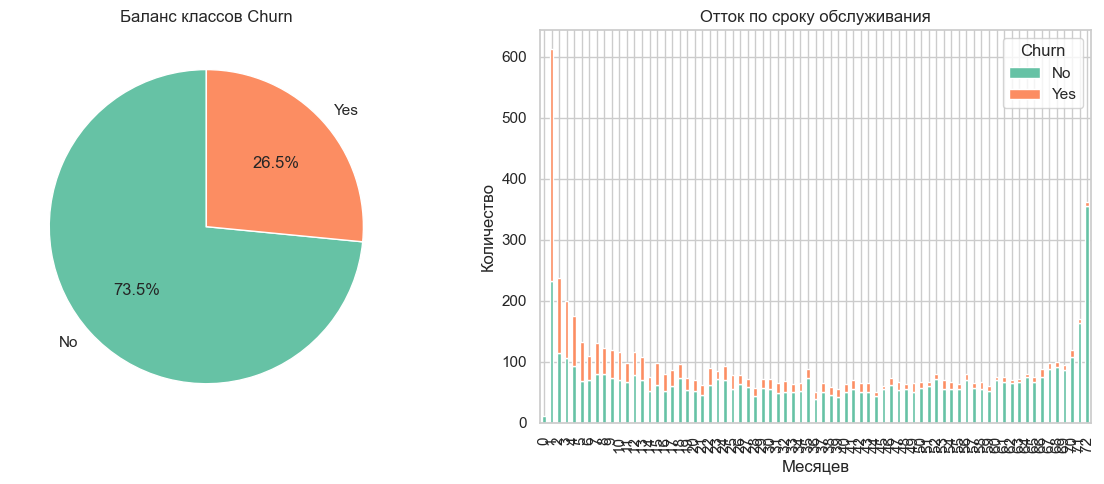


📈 Доля ушедших клиентов: 26.5%
📈 Доля оставшихся: 73.5%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Распределение классов
churn_counts = df["Churn"].value_counts()
axes[0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90
)
axes[0].set_title("Баланс классов Churn")

# По месяцам
churn_by_month = df.groupby(["tenure", "Churn"]).size().unstack()
churn_by_month.plot(kind="bar", stacked=True, ax=axes[1], color=["#66c2a5", "#fc8d62"])
axes[1].set_title("Отток по сроку обслуживания")
axes[1].set_xlabel("Месяцев")
axes[1].set_ylabel("Количество")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

# Считаем баланс
churn_rate = df["Churn"].value_counts(normalize=True)
print(f"\n📈 Доля ушедших клиентов: {churn_rate['Yes']:.1%}")
print(f"📈 Доля оставшихся: {churn_rate['No']:.1%}")

🔢 Числовые признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



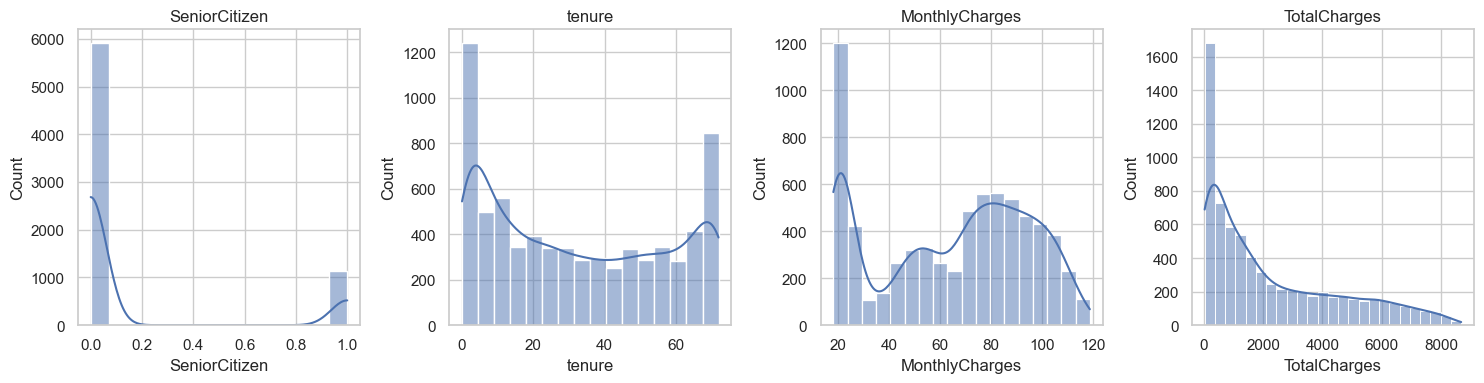


📊 Описательные статистики:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [8]:
# Определяем числовые колонки
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"🔢 Числовые признаки: {num_cols}\n")

# Распределения
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4c72b0")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Статистики
print("\n📊 Описательные статистики:")
display(df[num_cols].describe().T)

🔤 Категориальные признаки (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Количество уникальных значений:


,unique
gender,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3


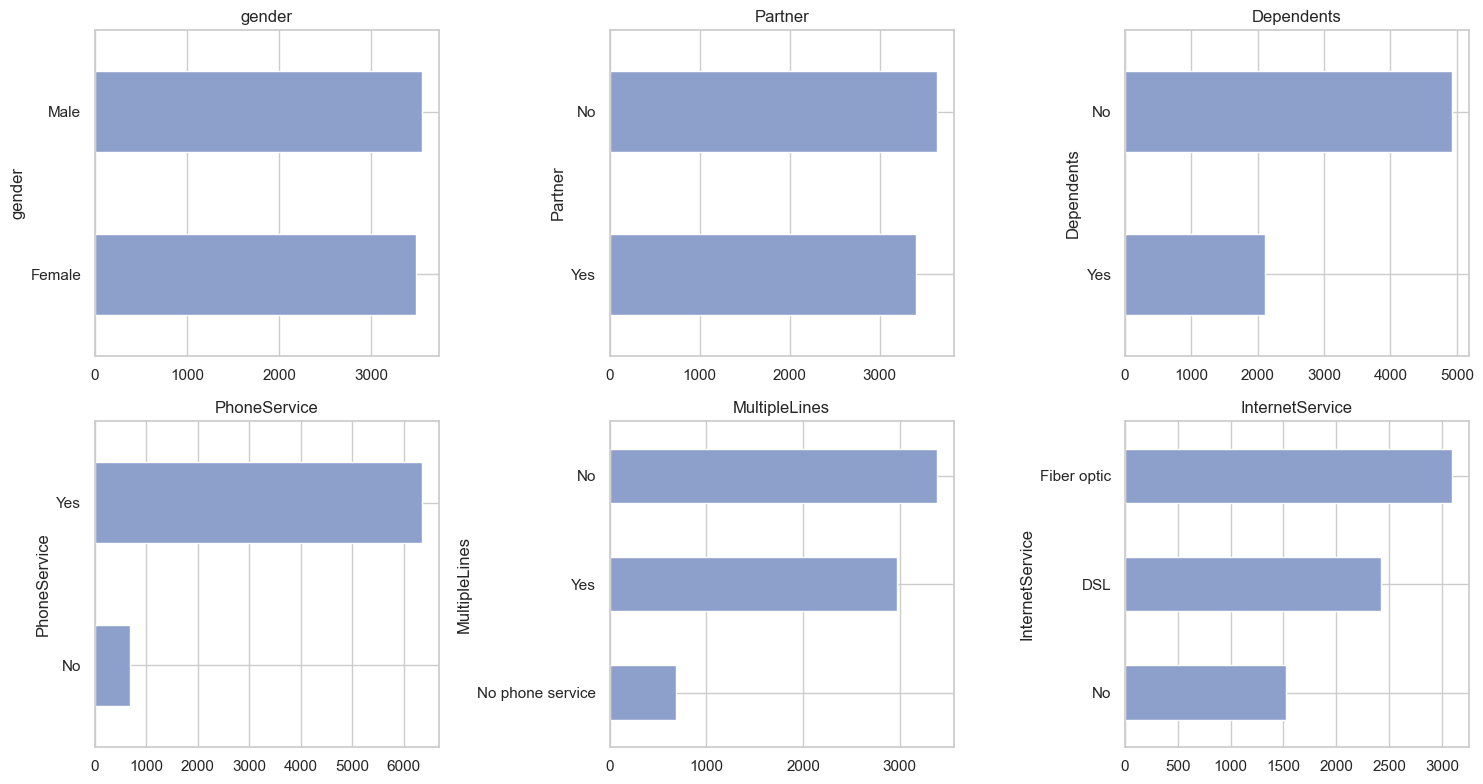

In [9]:
# Категориальные колонки (без customerID и Churn)
cat_cols = df.select_dtypes(include=["object"]).columns.drop(["customerID", "Churn"]).tolist()
print(f"🔤 Категориальные признаки ({len(cat_cols)}): {cat_cols}\n")

# Уникальные значения
unique_counts = df[cat_cols].nunique().sort_values()
print("Количество уникальных значений:")
display(unique_counts.to_frame("unique"))

# Топ-5 признаков с распределением
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    counts = df[col].value_counts()
    counts.plot(kind="barh", ax=axes[i], color="#8da0cb")
    axes[i].set_title(col)
    axes[i].invert_yaxis()
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

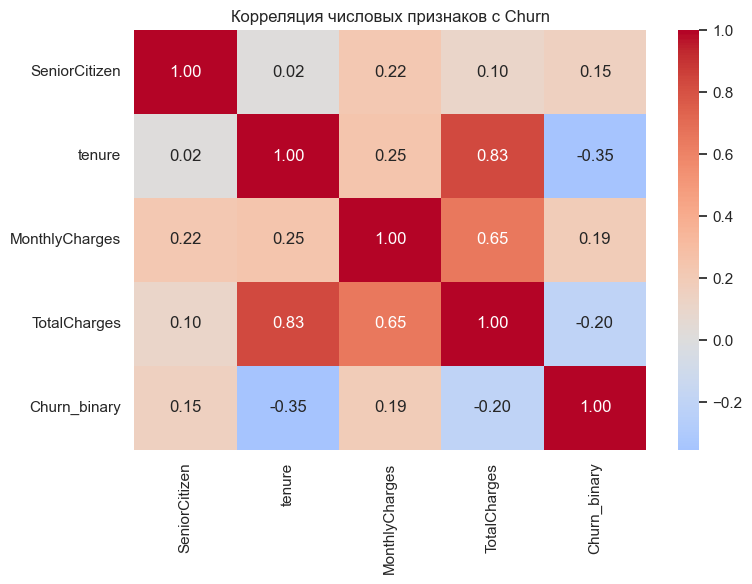


🔗 Корреляции с Churn:


MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_binary, dtype: float64

In [10]:
# Кодируем целевую переменную для корреляций
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

# Корреляционная матрица числовых признаков
corr_cols = num_cols + ["Churn_binary"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляция числовых признаков с Churn")
plt.tight_layout()
plt.show()

print("\n🔗 Корреляции с Churn:")
display(corr["Churn_binary"].drop("Churn_binary").sort_values(ascending=False))

In [11]:
# Сводная таблица по Churn
print("📊 Средние значения по группам Churn:")
display(df.groupby("Churn")[num_cols].mean().round(2))

# Критические сегменты
print("\n🎯 Отток по типу контракта:")
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index").round(3)
display(contract_churn)

print("\n🎯 Отток по способу оплаты:")
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").round(3)
display(payment_churn.sort_values("Yes", ascending=False))

📊 Средние значения по группам Churn:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.13,37.57,61.27,2555.34
Yes,0.25,17.98,74.44,1531.80



🎯 Отток по типу контракта:


Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028



🎯 Отток по способу оплаты:


Churn,No,Yes
PaymentMethod,,
Electronic check,0.547,0.453
Mailed check,0.809,0.191
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152


In [12]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          🎯 ВЫВОДЫ ДЛЯ MLOps-ПАЙПЛАЙНА                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. ПРЕПРОЦЕССИНГ:                                           ║
║     • TotalCharges: конвертация в float + обработка NaN     ║
║     • customerID: удалить из признаков                      ║
║     • Бинарные (Yes/No, Male/Female): label encoding        ║
║     • Мульти-категориальные: one-hot encoding               ║
║                                                              ║
║  2. МАСШТАБИРОВАНИЕ:                                         ║
║     • StandardScaler для числовых (MonthlyCharges, tenure)  ║
║     • Сохранить scaler как артефакт!                        ║
║                                                              ║
║  3. ДИСБАЛАНС КЛАССОВ:                                       ║
║     • 73% / 27% — умеренный                                 ║
║     • Метрики: ROC-AUC, F1, PR-AUC                          ║
║     • class_weight='balanced' в модели                      ║
║                                                              ║
║  4. ПРИЗНАКИ С НАИБОЛЬШЕЙ ИНФОРМАТИВНОСТЬЮ:                  ║
║     • tenure, Contract, MonthlyCharges, PaymentMethod       ║
║                                                              ║
║  5. ТРЕБОВАНИЯ К ПАЙПЛАЙНУ:                                  ║
║     • Все преобразования — в sklearn Pipeline               ║
║     • Никакого ручного кодирования в predict.py!            ║
║     • Версионировать scaler + модель вместе                 ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          🎯 ВЫВОДЫ ДЛЯ MLOps-ПАЙПЛАЙНА                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. ПРЕПРОЦЕССИНГ:                                           ║
║     • TotalCharges: конвертация в float + обработка NaN     ║
║     • customerID: удалить из признаков                      ║
║     • Бинарные (Yes/No, Male/Female): label encoding        ║
║     • Мульти-категориальные: one-hot encoding               ║
║                                                              ║
║  2. МАСШТАБИРОВАНИЕ:                                         ║
║     • StandardScaler для числовых (MonthlyCharges, tenure)  ║
║     • Сохранить scaler как артефакт!                        ║
║                                                              ║
║  3. ДИСБАЛАНС КЛАССОВ:                                       ║
║     • 73% / 27% — умеренный    